In [1]:
import pandas as pd
import os 
import numpy as np
os.chdir("/users/nathanielborland/Documents/UVM/Classes/2025 Fall/Bayesian Statistics/Bayesketball/bayesketball") ## change to your root
os.getcwd()
import seaborn as sns
from matplotlib import pyplot as plt
import time
from scipy.stats import norm

#  scipy.stats.norm

In [7]:
posterior_samples_att = pd.read_csv("results/general_attempt_non_possession_posterior.csv")
posterior_samples_att

,alpha,beta[1],beta[2],beta[3],beta[4],beta[5],beta[6],beta[7],beta[8],beta[9],beta[10],sigma,lp__
0,0.063467,0.227715,0.260190,0.215144,-0.304742,1.535326,0.487665,0.154211,0.150482,-1.153945,-0.049539,6.241654,-52139.460847
1,0.147048,0.221054,0.258609,0.225107,-0.292311,1.513766,0.494151,0.155388,0.146749,-1.151707,-0.023941,6.119360,-52142.050577
2,0.095823,0.217741,0.255616,0.217182,-0.268458,1.526829,0.493757,0.145663,0.165732,-1.163450,-0.024781,6.194221,-52139.211923
3,0.093077,0.208708,0.259861,0.191610,-0.274059,1.538333,0.482537,0.177231,0.146409,-1.157545,-0.073111,6.202815,-52136.917516
4,0.019445,0.206207,0.268784,0.206965,-0.271986,1.542840,0.479100,0.151297,0.128976,-1.195197,-0.066914,6.175081,-52144.909987
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.146525,0.178357,0.264656,0.169626,-0.249646,1.530099,0.481711,0.160169,0.144036,-1.182823,-0.085716,6.216939,-52142.177128
1996,0.123870,0.191126,0.252642,0.189901,-0.247627,1.526948,0.492054,0.166515,0.125576,-1.180263,-0.059344,6.185180,-52138.154500
1997,0.127930,0.180718,0.251383,0.188598,-0.242933,1.529133,0.491508,0.158798,0.136201,-1.194515,-0.046874,6.186708,-52137.628116
1998,0.030097,0.177837,0.262825,0.195586,-0.244988,1.528454,0.494497,0.142036,0.120915,-1.201989,-0.055731,6.149135,-52140.187674


Text(0.5, 1.0, '$\\beta_{10}$ (personal fouls)')

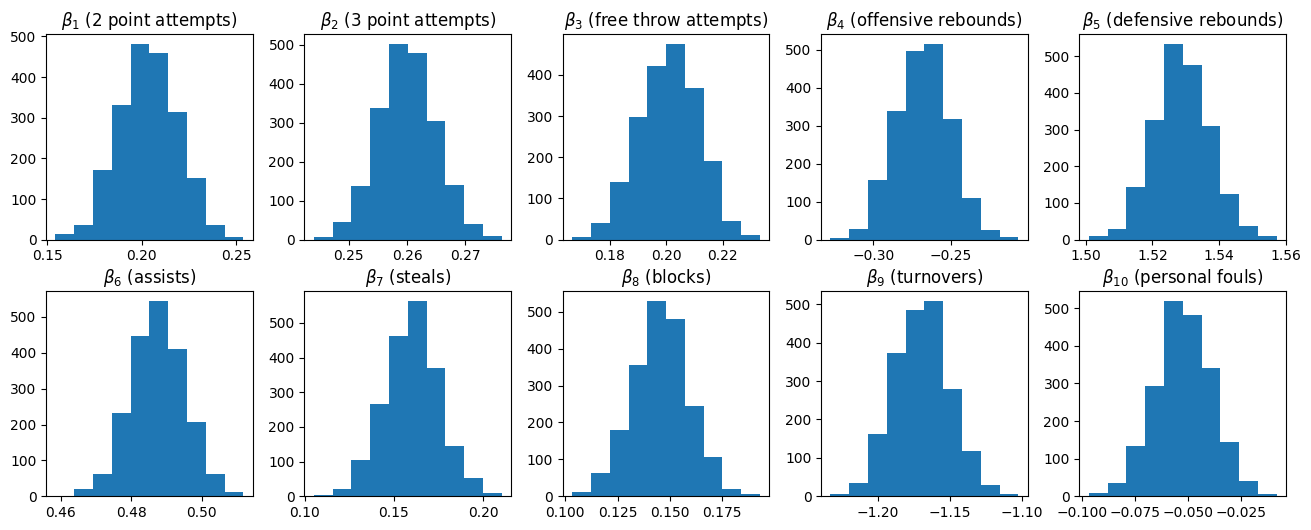

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(16,6))
fig.subplots_adjust(wspace=0.25, hspace=0.25)

axs[0,0].hist(posterior_samples_att['beta[1]'])
axs[0,0].set_title('$\\beta_1$ (2 point attempts)')

axs[0,1].hist(posterior_samples_att['beta[2]'])
axs[0,1].set_title('$\\beta_2$ (3 point attempts)')

axs[0,2].hist(posterior_samples_att['beta[3]'])
axs[0,2].set_title('$\\beta_3$ (free throw attempts)')

axs[0,3].hist(posterior_samples_att['beta[4]'])
axs[0,3].set_title('$\\beta_4$ (offensive rebounds)')

axs[0,4].hist(posterior_samples_att['beta[5]'])
axs[0,4].set_title('$\\beta_5$ (defensive rebounds)')

axs[1,0].hist(posterior_samples_att['beta[6]'])
axs[1,0].set_title('$\\beta_6$ (assists)')

axs[1,1].hist(posterior_samples_att['beta[7]'])
axs[1,1].set_title('$\\beta_7$ (steals)')

axs[1,2].hist(posterior_samples_att['beta[8]'])
axs[1,2].set_title('$\\beta_8$ (blocks)')

axs[1,3].hist(posterior_samples_att['beta[9]'])
axs[1,3].set_title('$\\beta_9$ (turnovers)')

axs[1,4].hist(posterior_samples_att['beta[10]'])
axs[1,4].set_title('$\\beta_{10}$ (personal fouls)')

fig.set_title('Posterior Sampled Parameter Distributions')

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16,6))
fig.subplots_adjust(wspace=0.25, hspace=0.25)



In [11]:
posterior_samples_pct = pd.read_csv("results/general_pct_non_possession_posterior.csv")
posterior_samples_pct

,alpha,beta[1],beta[2],beta[3],beta[4],beta[5],beta[6],beta[7],beta[8],beta[9],beta[10],sigma,lp__
0,0.099143,110.337729,17.532561,15.945422,0.651090,0.412259,0.174912,0.190489,0.007688,-0.901090,-0.333272,4.328376,-44175.195096
1,0.066892,109.936673,17.775036,15.754168,0.653561,0.419082,0.182606,0.190700,0.001680,-0.904620,-0.331519,4.308699,-44177.117115
2,0.075128,110.430693,17.785138,15.948986,0.645065,0.409152,0.176034,0.191485,0.013465,-0.909179,-0.329142,4.312384,-44178.009866
3,0.123062,109.864433,17.827611,15.732681,0.646734,0.408821,0.175950,0.179753,0.012233,-0.918684,-0.342161,4.339881,-44178.247097
4,0.063733,108.501351,17.584974,15.728230,0.646690,0.427576,0.181786,0.186778,0.018061,-0.919486,-0.327622,4.299448,-44180.367170
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.107154,111.262189,17.786362,16.292559,0.672231,0.399091,0.177732,0.184397,0.006890,-0.903694,-0.337488,4.321839,-44177.921646
1996,0.102598,111.554732,17.692664,15.876666,0.654671,0.403194,0.175504,0.194534,0.008542,-0.889427,-0.343579,4.340934,-44176.665093
1997,0.119346,111.542978,17.830123,16.326205,0.669739,0.399766,0.171408,0.178460,0.011002,-0.907323,-0.335849,4.322230,-44177.259519
1998,0.034884,112.022309,18.070022,15.674424,0.661274,0.392045,0.171101,0.187993,0.005758,-0.892188,-0.339117,4.340880,-44182.842344


Text(0.5, 1.0, '$\\beta_{10}$ (personal fouls)')

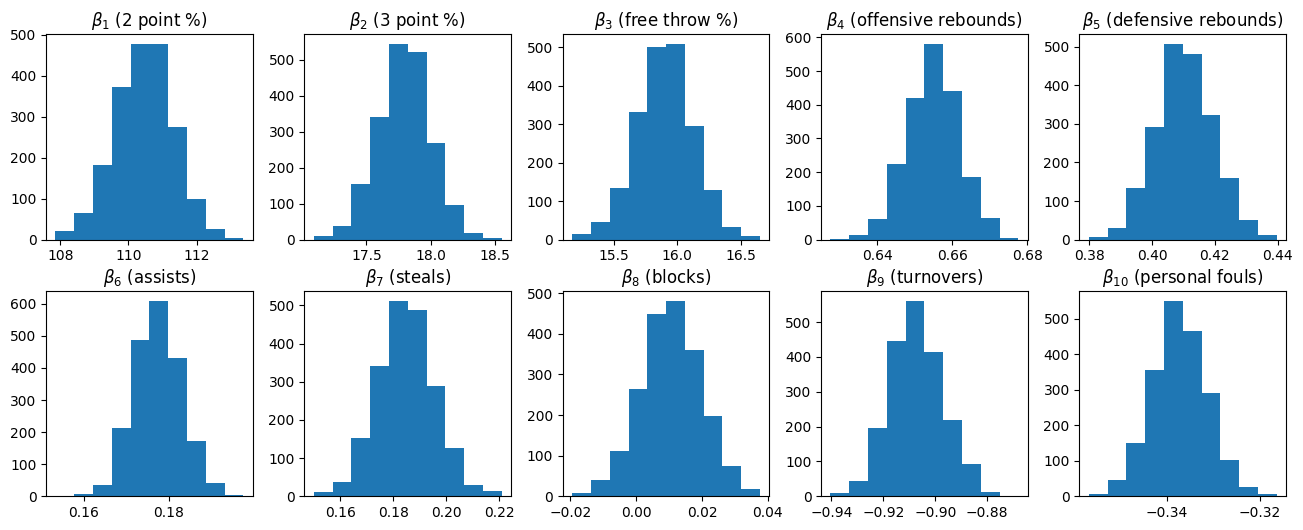

In [43]:
# fg3_pct_away,ft_pct_away,oreb_away,dreb_away,ast_away,stl_away,blk_away,tov_away,pf_away
fig, axs = plt.subplots(2, 5, figsize=(16,6))
fig.subplots_adjust(wspace=0.25, hspace=0.25)

axs[0,0].hist(posterior_samples_pct['beta[1]'])
axs[0,0].set_title('$\\beta_1$ (2 point %)')

axs[0,1].hist(posterior_samples_pct['beta[2]'])
axs[0,1].set_title('$\\beta_2$ (3 point %)')

axs[0,2].hist(posterior_samples_pct['beta[3]'])
axs[0,2].set_title('$\\beta_3$ (free throw %)')

axs[0,3].hist(posterior_samples_pct['beta[4]'])
axs[0,3].set_title('$\\beta_4$ (offensive rebounds)')

axs[0,4].hist(posterior_samples_pct['beta[5]'])
axs[0,4].set_title('$\\beta_5$ (defensive rebounds)')

axs[1,0].hist(posterior_samples_pct['beta[6]'])
axs[1,0].set_title('$\\beta_6$ (assists)')

axs[1,1].hist(posterior_samples_pct['beta[7]'])
axs[1,1].set_title('$\\beta_7$ (steals)')

axs[1,2].hist(posterior_samples_pct['beta[8]'])
axs[1,2].set_title('$\\beta_8$ (blocks)')

axs[1,3].hist(posterior_samples_pct['beta[9]'])
axs[1,3].set_title('$\\beta_9$ (turnovers)')

axs[1,4].hist(posterior_samples_pct['beta[10]'])
axs[1,4].set_title('$\\beta_{10}$ (personal fouls)')
